# Portafolio Cuantitativo Neutral al Mercado

## Pairs Trading en Forex mediante Cointegración y Filtro de Kalman

**Autor:** Edgar Samuel Oropeza García

**Institución:** Tec de Monterrey

**Área:** Finanzas Cuantitativas, Economía Estadística y Machine Learning

---

Este notebook implementa, paso a paso, un sistema de *Pairs Trading* (arbitraje estadístico) sobre el mercado de divisas (Forex). El objetivo es identificar pares de monedas cointegradas, estimar su relación de cobertura de forma dinámica con un Filtro de Kalman, y generar señales de entrada/salida basadas en la reversión a la media del spread — buscando retornos independientes de la dirección general del mercado (*market-neutral*).

## Instalación de Librerías

Se instalan las librerías necesarias para cada fase del proyecto. Las marcadas como opcionales corresponden a la extensión GNN (alternativa a TDA), que no es parte obligatoria del pipeline base.

In [22]:
# Fase 1
# %pip install yfinance oandapyV20 pandas numpy
# %pip install --upgrade yfinance

# Fase 2
# %pip install statsmodels scipy scikit-learn gudhi ripser kmapper networkx

# Fase 3
# %pip install pykalman filterpy

# Fase 4
# %pip install hmmlearn

# Fase 5
# %pip install vectorbt quantstats empyrical-reloaded

# Opcional — GNN (alternativa a TDA en Fase 2)
# %pip install torch torch-geometric

## Fase 1: Datos y EDA

Descargamos los precios históricos de las divisas del universo (12 monedas frente al USD), los alineamos en el tiempo y separamos cronológicamente en entrenamiento (in-sample) y validación (out-of-sample). Esta separación es clave: todo lo que se calibre en las fases siguientes (cointegración, umbrales, Kalman) se hace con el tramo de entrenamiento, para que el tramo de validación sirva como una prueba honesta.

In [23]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

pd.set_option('display.max_columns', None)

# Universo de 12 divisas de alta liquidez, expresadas como pares contra USD (formato yfinance)
tickers = {
    'EURUSD': 'EURUSD=X',
    'GBPUSD': 'GBPUSD=X',
    'AUDUSD': 'AUDUSD=X',
    'NZDUSD': 'NZDUSD=X',
    'USDJPY': 'USDJPY=X',
    'USDCAD': 'USDCAD=X',
    'USDCHF': 'USDCHF=X',
    'USDMXN': 'USDMXN=X',
    'USDCNY': 'USDCNY=X',
    'USDSEK': 'USDSEK=X',
    'USDNOK': 'USDNOK=X',
    'USDSGD': 'USDSGD=X',
}

In [24]:
# yfinance limita los intervalos de 60m a los últimos ~730 días
raw_data = yf.download(
    list(tickers.values()),
    period='729d',
    interval='60m',
    progress=False
)['Close']

raw_data.columns = tickers.keys()
raw_data.head()

,EURUSD,GBPUSD,AUDUSD,NZDUSD,USDJPY,USDCAD,USDCHF,USDMXN,USDCNY,USDSEK,USDNOK,USDSGD
Datetime,,,,,,,,,,,,
2023-11-17 00:00:00+00:00,0.646914,1.085658,1.241850,0.596587,1.37498,0.88855,NaN,150.569000,17.226400,10.92478,10.59150,1.34676
2023-11-17 01:00:00+00:00,0.646454,1.085541,1.241372,0.595770,1.37480,0.88888,7.2451,150.619003,17.222700,10.92760,10.58393,1.34787
2023-11-17 02:00:00+00:00,0.646580,1.085894,1.241080,0.595912,1.37480,0.88820,7.2447,150.460007,17.220400,10.92538,10.57920,1.34785
2023-11-17 03:00:00+00:00,0.646830,1.085658,1.240803,0.596125,1.37492,0.88820,7.2441,150.552002,17.218599,10.92789,10.58060,1.34800
2023-11-17 04:00:00+00:00,0.646956,1.085305,1.240602,0.596054,1.37490,0.88850,7.2443,150.570999,17.216999,10.93918,10.59200,1.34782


In [25]:
# Forex opera 24/5; puede haber pequeños huecos entre calendarios de distintos pares.
data = raw_data.copy().ffill().dropna()

print(f"Rango de fechas: {data.index.min()} a {data.index.max()}")
print(f"Número de observaciones: {len(data)}")
data.head()

Rango de fechas: 2023-11-17 01:00:00+00:00 a 2026-09-02 04:00:00+01:00
Número de observaciones: 17357


,EURUSD,GBPUSD,AUDUSD,NZDUSD,USDJPY,USDCAD,USDCHF,USDMXN,USDCNY,USDSEK,USDNOK,USDSGD
Datetime,,,,,,,,,,,,
2023-11-17 01:00:00+00:00,0.646454,1.085541,1.241372,0.595770,1.37480,0.88888,7.2451,150.619003,17.222700,10.92760,10.58393,1.34787
2023-11-17 02:00:00+00:00,0.646580,1.085894,1.241080,0.595912,1.37480,0.88820,7.2447,150.460007,17.220400,10.92538,10.57920,1.34785
2023-11-17 03:00:00+00:00,0.646830,1.085658,1.240803,0.596125,1.37492,0.88820,7.2441,150.552002,17.218599,10.92789,10.58060,1.34800
2023-11-17 04:00:00+00:00,0.646956,1.085305,1.240602,0.596054,1.37490,0.88850,7.2443,150.570999,17.216999,10.93918,10.59200,1.34782
2023-11-17 05:00:00+00:00,0.647082,1.085658,1.241511,0.596196,1.37490,0.88879,7.2432,150.630997,17.222000,10.93487,10.58185,1.34756


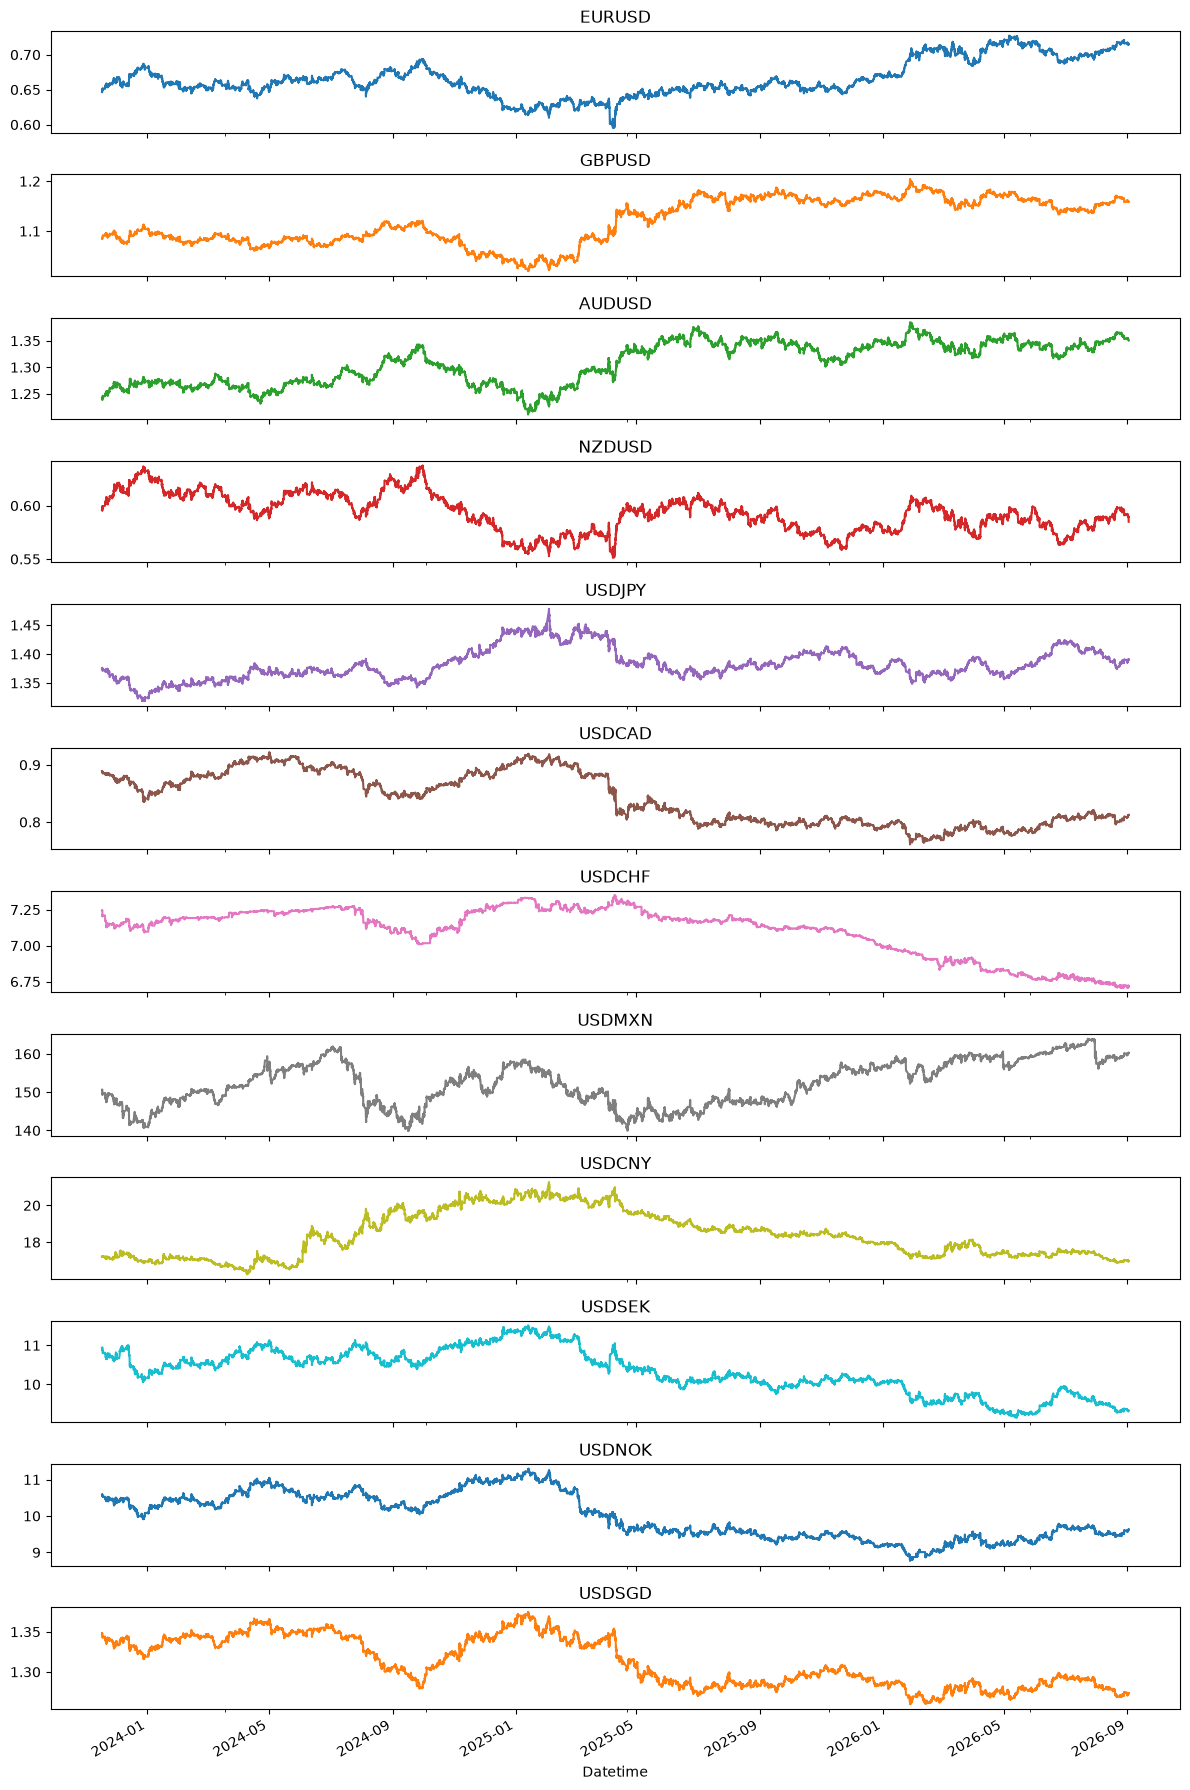

In [26]:
data.plot(subplots=True, figsize=(12, 18), title=list(data.columns), legend=False)
plt.tight_layout()
plt.show()

In [27]:
# Datos de entrenamiento y validacion

split_idx = int(len(data) * 0.70)
train = data.iloc[:split_idx]
test = data.iloc[split_idx:]

print(f"data: {data.shape} | train: {train.shape} | test: {test.shape}")

data: (17357, 12) | train: (12149, 12) | test: (5208, 12)


## Fase 2: Identificación Econométrica de Cointegración

Antes de armar cualquier señal de trading, hay que confirmar qué pares de divisas están relacionadas en el largo plazo (cointegrados), y no solo correlacionados por casualidad. Todo esto se calibra **únicamente con `train`**; el tramo de validación no se toca hasta el backtest final.

1. **ADF** sobre cada serie individual, para confirmar que son I(1) (no estacionarias por sí solas).
2. **Engle-Granger** par a par, para encontrar combinaciones de 2 divisas cuyo residuo sí sea estacionario.
3. **Johansen** sobre el universo completo, para detectar relaciones de equilibrio en canastas de 3+ divisas.

In [32]:
from statsmodels.tsa.stattools import adfuller, coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.stats.multitest import multipletests
from itertools import combinations

In [34]:
def adf_test(series: pd.Series, name: str) -> dict:
    clean = series.dropna()
    if len(clean) == 0:
        raise ValueError(f"La serie '{name}' está vacía después de dropna() — revisa la Fase 1.")
    result = adfuller(clean, autolag='AIC')
    return {
        'serie': name,
        'adf_stat': result[0],
        'p_value': result[1],
        'es_I1': result[1] > 0.05,
    }

In [35]:
def engle_granger_pairs(data: pd.DataFrame, significance: float = 0.05) -> pd.DataFrame:
    """
    Corre la prueba de Engle-Granger sobre todas las combinaciones de 2 divisas.
    H0: NO hay cointegración. p-value bajo -> rechazamos H0 -> sí hay cointegración.
    """
    results = []
    for asset1, asset2 in combinations(data.columns, 2):
        score, p_value, _ = coint(data[asset1], data[asset2])
        results.append({
            'par': f"{asset1}-{asset2}",
            'asset1': asset1,
            'asset2': asset2,
            'p_value': p_value,
            'cointegrado': p_value < significance,
        })
    return pd.DataFrame(results).sort_values('p_value').reset_index(drop=True)

eg_results = engle_granger_pairs(train)
eg_results

,par,asset1,asset2,p_value,cointegrado
0,NZDUSD-USDJPY,NZDUSD,USDJPY,0.007906,True
1,AUDUSD-USDSGD,AUDUSD,USDSGD,0.030794,True
2,GBPUSD-USDSEK,GBPUSD,USDSEK,0.057645,False
3,AUDUSD-USDCAD,AUDUSD,USDCAD,0.060765,False
4,USDSEK-USDNOK,USDSEK,USDNOK,0.075377,False
...,...,...,...,...,...
61,USDCAD-USDCNY,USDCAD,USDCNY,0.934128,False
62,GBPUSD-USDMXN,GBPUSD,USDMXN,0.951849,False
63,GBPUSD-NZDUSD,GBPUSD,NZDUSD,0.966761,False
64,GBPUSD-USDJPY,GBPUSD,USDJPY,0.968567,False


In [36]:
n_tests = len(eg_results)
bonferroni_alpha = 0.05 / n_tests

print(f"Número de pares probados: {n_tests}")
print(f"Umbral Bonferroni ajustado: {bonferroni_alpha:.5f} (vs. 0.05 sin ajustar)")

eg_results['cointegrado_bonferroni'] = eg_results['p_value'] < bonferroni_alpha

pares_candidatos = eg_results[eg_results['cointegrado_bonferroni']]
print(f"\nPares que sobreviven la corrección: {len(pares_candidatos)}")
pares_candidatos

Número de pares probados: 66
Umbral Bonferroni ajustado: 0.00076 (vs. 0.05 sin ajustar)

Pares que sobreviven la corrección: 0


,par,asset1,asset2,p_value,cointegrado,cointegrado_bonferroni


In [37]:
rejected, p_adj, _, _ = multipletests(eg_results['p_value'], alpha=0.05, method='fdr_bh')

eg_results['p_value_fdr'] = p_adj
eg_results['cointegrado_fdr'] = rejected

pares_candidatos_fdr = eg_results[eg_results['cointegrado_fdr']]
print(f"Pares que sobreviven FDR (Benjamini-Hochberg): {len(pares_candidatos_fdr)}")
pares_candidatos_fdr

Pares que sobreviven FDR (Benjamini-Hochberg): 0


,par,asset1,asset2,p_value,cointegrado,cointegrado_bonferroni,p_value_fdr,cointegrado_fdr
